# Data Speaks!! — LSTM for IMDB Sentiment Classification

This notebook trains an **LSTM** (Long Short-Term Memory) neural network on the IMDB movie review dataset for binary sentiment classification (Positive / Negative).

### Pipeline Steps
| Step | Description |
|------|-------------|
| 0 | Environment & directory setup |
| 1 | Load & verify raw data (25K train + 25K test) |
| 2 | Data audit — nulls, duplicates, text stats, HTML artifacts |
| 3 | Text cleaning — HTML strip, whitespace normalize, dedup |
| 4 | Stratified train/validation split (90/10, seed=42) |
| 5 | Vocabulary building & sequence tokenization (train-only) |
| 6 | LSTM model training (early stopping) & test-set evaluation |
| 7 | Export metrics CSV |

All artifacts are saved under **`lstm/`**.

---
## Step 0 — Environment & Directory Setup

In [1]:
import os
import sys
import time
import re
import html
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

# Reproductibility
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)

# Paths
DATA_DIR    = os.path.join("..", "processed")          # ../processed/
MODELS_DIR  = os.path.join(".", "models")
METRICS_DIR = os.path.join(".", "metrics")
PLOTS_DIR   = os.path.join(".", "plots")

for d in [MODELS_DIR, METRICS_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

# Devices
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {device}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM    : {vram_gb:.1f} GB")
else:
    print("No GPU detected — training will be slower on CPU.")
print(f"PyTorch : {torch.__version__}")

Device  : cuda
GPU     : NVIDIA GeForce RTX 5060 Laptop GPU
VRAM    : 8.5 GB
PyTorch : 2.12.0.dev20260408+cu128


---
## Step 1 — Acquire and Verify Data

In [2]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "imdb_train.csv"))
test_df  = pd.read_csv(os.path.join(DATA_DIR, "imdb_test.csv"))

print(f"Train shape   : {train_df.shape}")
print(f"Test  shape   : {test_df.shape}")
print(f"Columns       : {list(train_df.columns)}")
print(f"\nTrain label counts:\n{train_df['label'].value_counts().to_string()}")
print(f"\nTest  label counts:\n{test_df['label'].value_counts().to_string()}")

Train shape   : (25000, 2)
Test  shape   : (25000, 2)
Columns       : ['text', 'label']

Train label counts:
label
1    12500
0    12500

Test  label counts:
label
1    12500
0    12500


---
## Step 2 — Data Audit (Read-Only)

In [3]:
#Null 
print("Counting null values")
print(f"Train nulls:\n{train_df.isnull().sum()}")
print(f"\nTest nulls:\n{test_df.isnull().sum()}")

#Duplicate
train_dups = train_df.duplicated(subset=["text"]).sum()
test_dups  = test_df.duplicated(subset=["text"]).sum()
print(f"\nCounting Duplicates")
print(f"Train: {train_dups}  |  Test: {test_dups}")

# Text length
train_len = train_df["text"].str.len()
test_len  = test_df["text"].str.len()
print(f"\nStatistics of character length")
print(f"Train : min={train_len.min()}, max={train_len.max()}, "
      f"mean={train_len.mean():.1f}, median={train_len.median():.1f}")
print(f"Test  : min={test_len.min()}, max={test_len.max()}, "
      f"mean={test_len.mean():.1f}, median={test_len.median():.1f}")

# HTML
html_train = train_df["text"].str.contains("<br", regex=False).sum()
html_test  = test_df["text"].str.contains("<br", regex=False).sum()
print(f"\nChecking html tags")
print(f"Train: {html_train} ({html_train/len(train_df):.1%})")
print(f"Test:  {html_test}  ({html_test/len(test_df):.1%})")

#Sample
raw_tokens = [
    tok for txt in train_df["text"].sample(2000, random_state=SEED)
    for tok in txt.split()
]
top20 = Counter(raw_tokens).most_common(20)
print(f"\nTop 20 most common")
for word, cnt in top20:
    print(f"  {word:<15} {cnt}")


Counting null values
Train nulls:
text     0
label    0
dtype: int64

Test nulls:
text     0
label    0
dtype: int64

Counting Duplicates
Train: 96  |  Test: 199

Statistics of character length
Train : min=52, max=13704, mean=1325.1, median=979.0
Test  : min=32, max=12988, mean=1293.8, median=962.0

Checking html tags
Train: 14665 (58.7%)
Test:  14535  (58.1%)

Top 20 most common
  the             23561
  a               12292
  and             12173
  of              11395
  to              10711
  is              8173
  in              6965
  I               5242
  that            5079
  this            4550
  it              4340
  /><br           4138
  was             3763
  with            3428
  as              3391
  for             3304
  The             2734
  but             2722
  movie           2461
  on              2401


---
## Step 3 — Clean the Text

In [4]:
def clean_text(text: str) -> str:
    """Strip HTML tags/entities, normalize whitespace."""
    text = html.unescape(text)                                    # decode &amp; etc.
    text = re.sub(r"<br\s*/?>", " ", text, flags=re.IGNORECASE)  # <br /> → space
    text = re.sub(r"<[^>]+>", " ", text)                         # any remaining tags
    text = re.sub(r"\s+", " ", text).strip()                     # collapse whitespace
    return text

# Apply cleaning
train_df["text_clean"] = train_df["text"].apply(clean_text)
test_df["text_clean"]  = test_df["text"].apply(clean_text)

# Remove exact duplicates (keep first occurrence)
train_clean = (
    train_df.drop_duplicates(subset=["text_clean"], keep="first")
    .copy()[["text_clean", "label"]]
    .rename(columns={"text_clean": "text"})
)
test_clean = (
    test_df.drop_duplicates(subset=["text_clean"], keep="first")
    .copy()[["text_clean", "label"]]
    .rename(columns={"text_clean": "text"})
)

print(f"Train rows: {len(train_df)} to {len(train_clean)} (removed {len(train_df)-len(train_clean)} duplicates)")
print(f"Test  rows: {len(test_df)}  to {len(test_clean)}  (removed {len(test_df)-len(test_clean)} duplicates)")

# Save cleaned datasets
train_clean.to_csv("imdb_train_clean.csv", index=False)
test_clean.to_csv("imdb_test_clean.csv", index=False)
print(f"Saved cleaned CSVs to lstm/")

Train rows: 25000 to 24902 (removed 98 duplicates)
Test  rows: 25000  to 24799  (removed 201 duplicates)
Saved cleaned CSVs to lstm/


---
## Step 4 — Train / Validation Split

In [5]:
train_split, val_split = train_test_split(
    train_clean,
    test_size=0.10,
    random_state=SEED,
    stratify=train_clean["label"],
)

print(f"Train subset : {len(train_split):>6}  ({len(train_split)/len(train_clean):.1%})")
print(f"Val   subset : {len(val_split):>6}  ({len(val_split)/len(train_clean):.1%})")
print(f"Test  (held) : {len(test_clean):>6}")

print(f"\nTrain label balance:\n{train_split['label'].value_counts(normalize=True).to_string()}")
print(f"\nVal   label balance:\n{val_split['label'].value_counts(normalize=True).to_string()}")


Train subset :  22411  (90.0%)
Val   subset :   2491  (10.0%)
Test  (held) :  24799

Train label balance:
label
1    0.500781
0    0.499219

Val   label balance:
label
1    0.501004
0    0.498996


---
## Step 5 — Vocabulary Building & Sequence Tokenization

Build vocabulary from **training split only** (no data leakage). Convert text to padded integer sequences.

In [6]:
# Simple whitespace tokenizer
def tokenize(text):
    """Lowercase + split on whitespace."""
    return text.lower().split()

# Build vocabulary from TRAINING split only
word_counts = Counter()
for text in train_split["text"]:
    word_counts.update(tokenize(text))

VOCAB_SIZE = 25000  # keep top 25K words
PAD_IDX = 0
UNK_IDX = 1

# word → index mapping
most_common = word_counts.most_common(VOCAB_SIZE - 2)  # -2 for PAD and UNK
word2idx = {"<PAD>": PAD_IDX, "<UNK>": UNK_IDX}
for idx, (word, _) in enumerate(most_common, start=2):
    word2idx[word] = idx

print(f"Total unique tokens in training set: {len(word_counts)}")
print(f"Vocabulary size (with PAD+UNK)     : {len(word2idx)}")

# Determine max sequence length (95th percentile)
train_token_lengths = [len(tokenize(t)) for t in train_split["text"]]
p95 = int(np.percentile(train_token_lengths, 95))
MAX_LEN = min(p95, 500)  # cap at 500 to be safe
print(f"Token length 95th percentile       : {p95}")
print(f"MAX_LEN (used for padding)         : {MAX_LEN}")

# Convert text to padded integer sequences 
def text_to_sequence(text, word2idx, max_len):
    tokens = tokenize(text)
    seq = [word2idx.get(t, UNK_IDX) for t in tokens[:max_len]]
    # Pad to max_len
    seq += [PAD_IDX] * (max_len - len(seq))
    return seq

X_train = np.array([text_to_sequence(t, word2idx, MAX_LEN) for t in train_split["text"]])
X_val   = np.array([text_to_sequence(t, word2idx, MAX_LEN) for t in val_split["text"]])
X_test  = np.array([text_to_sequence(t, word2idx, MAX_LEN) for t in test_clean["text"]])

y_train = train_split["label"].values
y_val   = val_split["label"].values
y_test  = test_clean["label"].values

print(f"\nFeature shapes:")
print(f"  X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"  X_val  : {X_val.shape}  y_val  : {y_val.shape}")
print(f"  X_test : {X_test.shape}  y_test : {y_test.shape}")

# Save vocabulary
vocab_path = "lstm_word2idx.pkl"
with open(vocab_path, "wb") as f:
    pickle.dump(word2idx, f)
print(f"Saved vocabulary → {vocab_path}")

Total unique tokens in training set: 221641
Vocabulary size (with PAD+UNK)     : 25000
Token length 95th percentile       : 594
MAX_LEN (used for padding)         : 500

Feature shapes:
  X_train: (22411, 500)  y_train: (22411,)
  X_val  : (2491, 500)  y_val  : (2491,)
  X_test : (24799, 500)  y_test : (24799,)
Saved vocabulary → lstm_word2idx.pkl


---
## Step 6 — LSTM Model Definition & Training

In [7]:
# Dataset
class IMDBSeqDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels    = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

BATCH_SIZE = 64

train_loader = DataLoader(IMDBSeqDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(IMDBSeqDataset(X_val, y_val),     batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(IMDBSeqDataset(X_test, y_test),   batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoader batches → train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}")

DataLoader batches → train=351, val=39, test=388


In [8]:
# LSTM Model
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim,
                 n_layers, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)  # *2 for bidirectional

    def forward(self, x):
        # x: (batch, seq_len)
        embedded = self.dropout(self.embedding(x))       # (batch, seq_len, embed_dim)
        output, (hidden, cell) = self.lstm(embedded)
        # Concatenate last hidden states from both directions
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)  # (batch, hidden*2)
        hidden = self.dropout(hidden)
        return self.fc(hidden)                           # (batch, output_dim)

# Hyperparameters
EMBED_DIM  = 128
HIDDEN_DIM = 256
N_LAYERS   = 2
DROPOUT    = 0.5
LR         = 1e-3
MAX_EPOCHS = 20
PATIENCE   = 3     # early stopping patience

model = SentimentLSTM(
    vocab_size=len(word2idx),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=2,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
    pad_idx=PAD_IDX,
).to(device)

optimizer = Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,} total, {trainable:,} trainable")
print(model)

Model parameters: 5,568,514 total, 5,568,514 trainable
SentimentLSTM(
  (embedding): Embedding(25000, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=2, bias=True)
)


In [9]:
# ── Training Loop with Early Stopping ─────────────────────────
history = {"train_loss": [], "val_loss": [], "val_acc": []}
best_val_loss = float("inf")
patience_counter = 0
best_model_path = os.path.join(MODELS_DIR, "lstm_best.pt")

print(f"Training LSTM for up to {MAX_EPOCHS} epochs (early stopping patience={PATIENCE}) on {device}…")
t0 = time.time()

for epoch in range(MAX_EPOCHS):
    t_epoch = time.time()

    # ── Training ──────────────────────────────────────────────
    model.train()
    running_loss = 0.0

    for step, (seqs, lbls) in enumerate(train_loader, 1):
        seqs, lbls = seqs.to(device), lbls.to(device)

        optimizer.zero_grad()
        logits = model(seqs)
        loss = criterion(logits, lbls)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        running_loss += loss.item()

    avg_train = running_loss / len(train_loader)

    # ── Validation ────────────────────────────────────────────
    model.eval()
    val_loss_sum = 0.0
    vp, vt = [], []

    with torch.no_grad():
        for seqs, lbls in val_loader:
            seqs, lbls = seqs.to(device), lbls.to(device)
            logits = model(seqs)
            loss = criterion(logits, lbls)
            val_loss_sum += loss.item()
            vp.extend(torch.argmax(logits, 1).cpu().numpy())
            vt.extend(lbls.cpu().numpy())

    avg_val = val_loss_sum / len(val_loader)
    v_acc   = accuracy_score(vt, vp)

    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)
    history["val_acc"].append(v_acc)

    dt = time.time() - t_epoch
    print(f"  Epoch {epoch+1:>2}/{MAX_EPOCHS}  ({dt:.1f}s) │ "
          f"train_loss={avg_train:.4f}  val_loss={avg_val:.4f}  val_acc={v_acc:.4f}", end="")

    # ── Early stopping check ──────────────────────────────────
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print("  ★ saved")
    else:
        patience_counter += 1
        print(f"  (patience {patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\n  Early stopping triggered at epoch {epoch+1}.")
            break

total_wall_time = time.time() - t0
print(f"\nTotal training wall-clock: {total_wall_time:.1f}s  ({total_wall_time/60:.1f} min)")
print(f"Best validation loss: {best_val_loss:.4f}")

Training LSTM for up to 20 epochs (early stopping patience=3) on cuda…
  Epoch  1/20  (45.9s) │ train_loss=0.6831  val_loss=0.6827  val_acc=0.5833  ★ saved
  Epoch  2/20  (46.5s) │ train_loss=0.6651  val_loss=0.6046  val_acc=0.6728  ★ saved
  Epoch  3/20  (45.7s) │ train_loss=0.6402  val_loss=0.6477  val_acc=0.6784  (patience 1/3)
  Epoch  4/20  (45.5s) │ train_loss=0.5399  val_loss=0.4683  val_acc=0.7744  ★ saved
  Epoch  5/20  (46.5s) │ train_loss=0.4568  val_loss=0.3854  val_acc=0.8322  ★ saved
  Epoch  6/20  (46.5s) │ train_loss=0.4017  val_loss=0.4147  val_acc=0.8246  (patience 1/3)
  Epoch  7/20  (44.1s) │ train_loss=0.3468  val_loss=0.3618  val_acc=0.8527  ★ saved
  Epoch  8/20  (41.4s) │ train_loss=0.3818  val_loss=0.3229  val_acc=0.8671  ★ saved
  Epoch  9/20  (41.9s) │ train_loss=0.3179  val_loss=0.3052  val_acc=0.8788  ★ saved
  Epoch 10/20  (47.7s) │ train_loss=0.2788  val_loss=0.3222  val_acc=0.8812  (patience 1/3)
  Epoch 11/20  (43.5s) │ train_loss=0.2444  val_loss=0.326

### Training & Validation Loss Curve

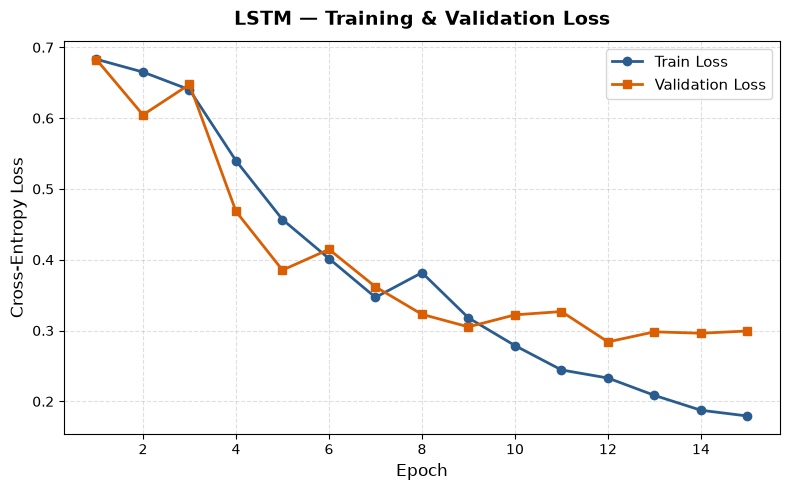

In [10]:
num_epochs_run = len(history["train_loss"])
epochs_x = range(1, num_epochs_run + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs_x, history["train_loss"], "o-", label="Train Loss",color="#2b5c8f", linewidth=2)
ax.plot(epochs_x, history["val_loss"],   "s-", label="Validation Loss",color="#d95f02", linewidth=2)
ax.set_title("LSTM — Training & Validation Loss", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Cross-Entropy Loss", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, ls="--", alpha=0.4)
fig.tight_layout()

loss_png = os.path.join(PLOTS_DIR, "lstm_loss_curve.png")
fig.savefig(loss_png, dpi=300)
plt.show()


---
## Step 6 (cont.) — Test-Set Evaluation & Verification

In [11]:
# Load best model weights
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

y_pred_list, y_true_list = [], []

with torch.no_grad():
    for seqs, lbls in test_loader:
        seqs, lbls = seqs.to(device), lbls.to(device)
        logits = model(seqs)
        y_pred_list.extend(torch.argmax(logits, 1).cpu().numpy())
        y_true_list.extend(lbls.cpu().numpy())

y_pred = np.array(y_pred_list)
y_true = np.array(y_true_list)

# Calculating metrics
acc = accuracy_score(y_true, y_pred)
p_m, r_m, f1_m, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")
p_c, r_c, f1_c, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
cm = confusion_matrix(y_true, y_pred)

print("═" * 50)
print("         LSTM — TEST SET RESULTS")
print("═" * 50)
print(f"Accuracy         : {acc:.4f}  ({acc*100:.2f}%)")
print(f"Macro Precision  : {p_m:.4f}")
print(f"Macro Recall     : {r_m:.4f}")
print(f"Macro F1         : {f1_m:.4f}")
print(f"Class 0 (Neg) F1 : {f1_c[0]:.4f}")
print(f"Class 1 (Pos) F1 : {f1_c[1]:.4f}")
print("\nFull Classification Report:")
print(classification_report(y_true, y_pred,target_names=["Negative", "Positive"], digits=4))

══════════════════════════════════════════════════
         LSTM — TEST SET RESULTS
══════════════════════════════════════════════════
Accuracy         : 0.8778  (87.78%)
Macro Precision  : 0.8795
Macro Recall     : 0.8779
Macro F1         : 0.8777
Class 0 (Neg) F1 : 0.8814
Class 1 (Pos) F1 : 0.8739

Full Classification Report:
              precision    recall  f1-score   support

    Negative     0.8533    0.9114    0.8814     12360
    Positive     0.9056    0.8444    0.8739     12439

    accuracy                         0.8778     24799
   macro avg     0.8795    0.8779    0.8777     24799
weighted avg     0.8795    0.8778    0.8776     24799



### Confusion Matrix

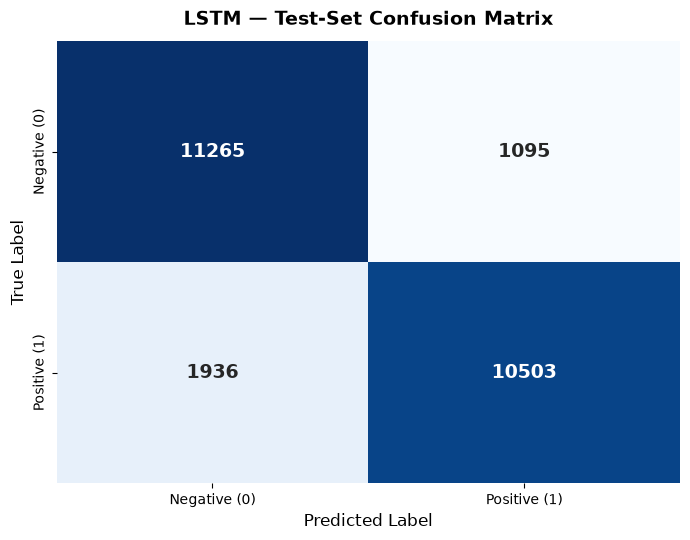

In [12]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["Negative (0)", "Positive (1)"],
    yticklabels=["Negative (0)", "Positive (1)"],
    annot_kws={"size": 14, "weight": "bold"}, ax=ax,
)
ax.set_title("LSTM — Test-Set Confusion Matrix",fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
fig.tight_layout()

cm_png = os.path.join(PLOTS_DIR, "lstm_confusion_matrix.png")
fig.savefig(cm_png, dpi=300)
plt.show()

---
## Step 7 — Export Metrics CSV

In [13]:
metrics_df = pd.DataFrame({
    "Model":             ["LSTM (Bidirectional, 2-layer)"],
    "Accuracy":          [round(acc, 4)],
    "Precision_Macro":   [round(p_m, 4)],
    "Recall_Macro":      [round(r_m, 4)],
    "F1_Macro":          [round(f1_m, 4)],
    "F1_Class0_Neg":     [round(f1_c[0], 4)],
    "F1_Class1_Pos":     [round(f1_c[1], 4)],
    "Training_Time_Sec": [round(total_wall_time, 1)],
})

csv_path = os.path.join(METRICS_DIR, "lstm_metrics.csv")
metrics_df.to_csv(csv_path, index=False)
print(f"Saved metrics → {csv_path}\n")
metrics_df

Saved metrics → .\metrics\lstm_metrics.csv



,Model,Accuracy,Precision_Macro,Recall_Macro,F1_Macro,F1_Class0_Neg,F1_Class1_Pos,Training_Time_Sec
0,"LSTM (Bidirectional, 2-layer)",0.8778,0.8795,0.8779,0.8777,0.8814,0.8739,831.4
